Loading data and model objects...
  Best model   : XGBoost
  Threshold    : 0.377
  Test samples : 6,519

E1: Re-engineering features on full dataset...
  Full dataset rows: 32,593
  Features: 19

E2: Generating dropout risk scores for all students...
  Dropout probability range: 0.001 – 0.995
  Mean probability: 0.332

  Risk tier distribution:
    HIGH      8,180  (25.1%)  ████████████
    MEDIUM    4,212  (12.9%)  ██████
    LOW      20,201  (62.0%)  ██████████████████████████████

E3: Building risk score table...
  Full risk table saved → ./outputs/phase4/block_e/E3_student_risk_scores.csv
  Total students scored: 32,593

E4: Plotting risk tier distribution...


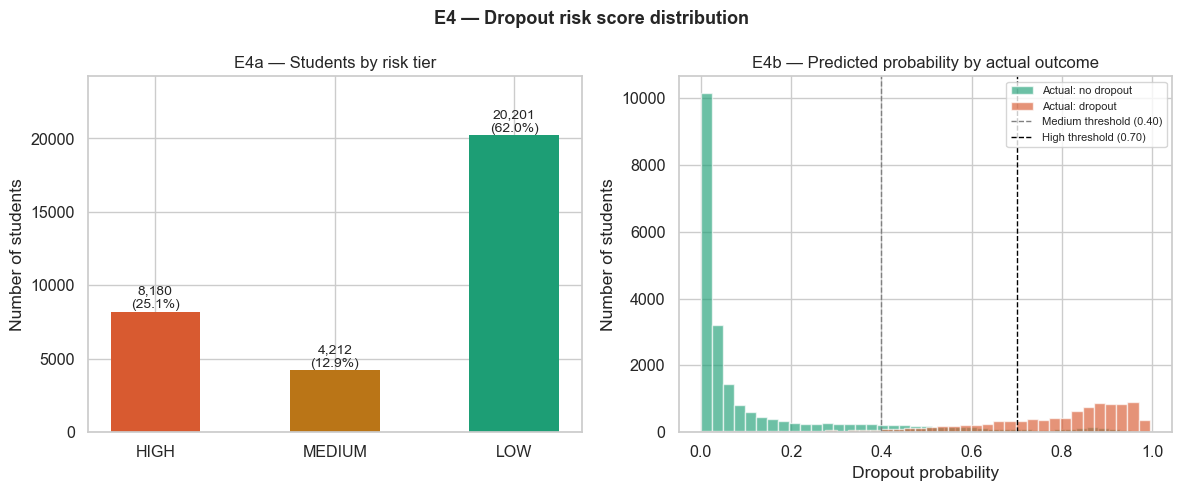

  Saved → ./outputs/phase4/block_e/E4_risk_distribution.png

E5: Printing top 20 highest-risk students...

  Top 20 highest-risk students (ranked by dropout probability):
      id_student code_module gender age_band      highest_education imd_band  mean_score  pct_submitted  num_of_prev_attempts  dropout_probability risk_tier final_result
rank                                                                                                                                                                     
1          69489         CCC      M     0-35     Lower Than A Level   80-90%         NaN            NaN                     0               0.9945      HIGH    Withdrawn
2         674814         CCC      M     0-35     Lower Than A Level   80-90%         NaN            NaN                     0               0.9941      HIGH    Withdrawn
3         674814         FFF      M     0-35     Lower Than A Level   80-90%         NaN            NaN                     0               0.9941   

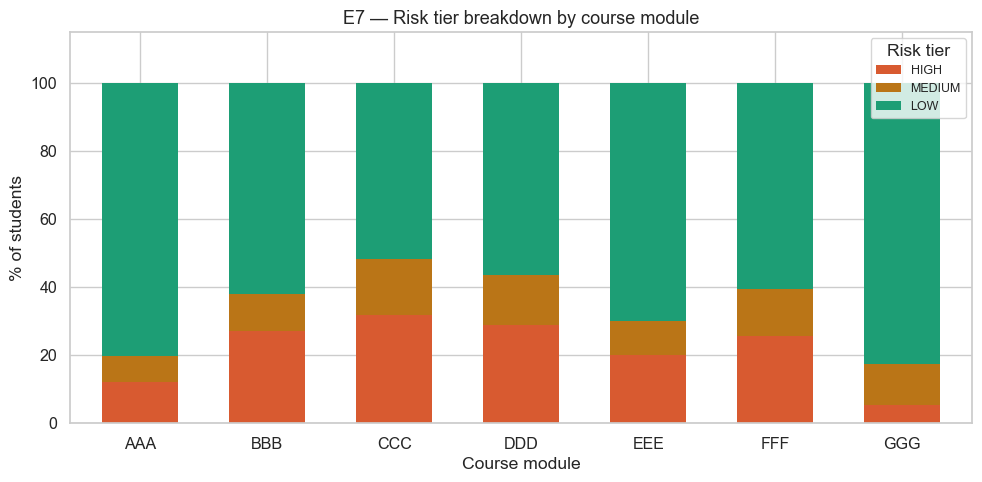

  Saved → ./outputs/phase4/block_e/E7_risk_by_module.png

BLOCK E COMPLETE — Student Dropout Risk Scoring

  Model used       : XGBoost
  Threshold        : 0.377
  Total students scored : 32,593

  Risk tier summary:
    🔴 HIGH   (p ≥ 0.70) : 8,180  (25.1%)
    🟡 MEDIUM (p 0.40–0.69): 4,212  (12.9%)
    🟢 LOW    (p < 0.40) : 20,201  (62.0%)

  Key outputs:
    ✅ E3_student_risk_scores.csv  — full scored table (all 32,593 students)
    ✅ E5_top20_highest_risk.csv   — top 20 for advisor intervention

  Charts saved to: ./outputs/phase4/block_e/
    E4_risk_distribution.png
    E7_risk_by_module.png

─────────────────────────────────────────────────────────
Next → Run phase4_block_f_shap.py
─────────────────────────────────────────────────────────



In [1]:
"""
=============================================================
Phase 4 — Block E: Student Dropout Risk Scoring
=============================================================
Goal: Use the best model from Block D to assign every student
      a dropout probability and a risk tier, then produce a
      ranked at-risk student table ready for intervention.

This is the CORE DELIVERABLE of the project.

A real institution would use this table to:
  • Prioritise which students advisors should contact first
  • Identify what risk factors are driving each student's score
  • Schedule early interventions before students withdraw

Risk tiers:
  HIGH   probability >= 0.70  → immediate outreach recommended
  MEDIUM probability 0.40–0.69 → monitor closely, optional outreach
  LOW    probability < 0.40   → no action needed

Outputs:
  E1 — Full student risk score table (CSV)
  E2 — Risk tier distribution plot
  E3 — Probability distribution histogram by outcome
  E4 — Top 20 highest-risk students table
"""

import os
import pickle
import warnings
warnings.filterwarnings('ignore')

from datetime import date
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Config
BLOCK_A_PATH = './outputs/phase4/block_a/'
BLOCK_D_PATH = './outputs/phase4/block_d/'
DATA_PATH    = './data/'
OUTPUT_PATH  = './outputs/phase4/block_e/'
os.makedirs(OUTPUT_PATH, exist_ok=True)

COLORS = {
    'blue':   '#3B8BD4',
    'teal':   '#1D9E75',
    'coral':  '#D85A30',
    'gray':   '#888780',
    'purple': '#7F77DD',
    'amber':  '#BA7517',
}
TIER_COLORS = {
    'HIGH':   COLORS['coral'],
    'MEDIUM': COLORS['amber'],
    'LOW':    COLORS['teal'],
}
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
RANDOM_STATE = 42


# =============================================================
# LOAD DATA AND MODEL OBJECTS
# =============================================================
print("Loading data and model objects...")

# Raw student data (for readable output — names, module codes etc.)
si = pd.read_csv(DATA_PATH + 'studentInfo.csv')
sa = pd.read_csv(DATA_PATH + 'studentAssessment.csv')
sr = pd.read_csv(DATA_PATH + 'studentRegistration.csv')
assessments = pd.read_csv(DATA_PATH + 'assessments.csv')

si['dropout'] = (si['final_result'] == 'Withdrawn').astype(int)

# Block A pipeline (for transforming new data)
with open(os.path.join(BLOCK_A_PATH, 'block_a_objects.pkl'), 'rb') as f:
    a_obj = pickle.load(f)

pipeline     = a_obj['pipeline']
FEATURES     = a_obj['feature_names']
X_test_raw   = a_obj['X_test_raw']   # unscaled test features
y_test       = a_obj['y_test']

# Block D best model
with open(os.path.join(BLOCK_D_PATH, 'block_d_objects.pkl'), 'rb') as f:
    d_obj = pickle.load(f)

best_model      = d_obj['best_model']
best_model_name = d_obj['best_model_name']
best_threshold  = d_obj['best_threshold']
X_test_scaled   = d_obj['X_test']

print(f"  Best model   : {best_model_name}")
print(f"  Threshold    : {best_threshold:.3f}")
print(f"  Test samples : {len(y_test):,}\n")


# =============================================================
# E1: Re-engineer features on the FULL dataset
# =============================================================
# We scored only the test split during training.
# For the deliverable, we score ALL students so the institution
# gets a complete picture.

print("E1: Re-engineering features on full dataset...")

df = si.copy()

# --- Same encodings as Block A ---
edu_map = {
    'No Formal quals': 0, 'Lower Than A Level': 1,
    'A Level or Equivalent': 2, 'HE Qualification': 3,
    'Post Graduate Qualification': 4
}
imd_map = {
    '0-10%': 0,'10-20': 1,'20-30%': 2,'30-40%': 3,'40-50%': 4,
    '50-60%': 5,'60-70%': 6,'70-80%': 7,'80-90%': 8,'90-100%': 9
}
df['edu_enc']    = df['highest_education'].map(edu_map)
df['imd_enc']    = df['imd_band'].map(imd_map)
df['age_enc']    = df['age_band'].map({'0-35': 0, '35-55': 1, '55<=': 2})
df['gender_enc'] = (df['gender'] == 'M').astype(int)
df['disab_enc']  = (df['disability'] == 'Y').astype(int)

# Assessment features
sa_meta = sa.merge(assessments[['id_assessment','date']], on='id_assessment', how='left')
sa_meta['days_early'] = sa_meta['date'] - sa_meta['date_submitted']
assess_feats = (
    sa_meta.groupby('id_student')
    .agg(mean_score=('score','mean'), std_score=('score','std'),
         n_assessments=('score','count'), mean_days_early=('days_early','mean'),
         first_score=('score','first'))
    .reset_index()
)
assess_feats['std_score'] = assess_feats['std_score'].fillna(0)

total_per_module = (
    assessments.groupby(['code_module','code_presentation'])
    .size().reset_index(name='total_assessments')
)
df = df.merge(total_per_module, on=['code_module','code_presentation'], how='left')
df = df.merge(assess_feats, on='id_student', how='left')
df['pct_submitted'] = (df['n_assessments'] / df['total_assessments']).clip(0, 1)

# Registration timing
reg_feats = (
    sr[['id_student','code_module','code_presentation','date_registration']]
    .drop_duplicates(subset=['id_student','code_module','code_presentation'])
)
df = df.merge(reg_feats, on=['id_student','code_module','code_presentation'], how='left')
df.rename(columns={'date_registration': 'days_to_start'}, inplace=True)
df['late_registration'] = (df['days_to_start'] > 0).astype(int)

# Interaction terms
df['edu_x_imd']        = df['edu_enc'] * df['imd_enc']
df['attempts_x_score'] = df['num_of_prev_attempts'] * df['mean_score'].fillna(0)
df['age_x_credits']    = df['age_enc'] * df['studied_credits']
df['first_score_x_n']  = df['first_score'].fillna(0) * df['n_assessments'].fillna(0)

print(f"  Full dataset rows: {len(df):,}")
print(f"  Features: {len(FEATURES)}\n")


# =============================================================
# E2: Score every student
# =============================================================
print("E2: Generating dropout risk scores for all students...")

# Extract feature matrix for all students
X_all = df[FEATURES]

# Transform using the FITTED pipeline from Block A (no refit)
X_all_scaled = pipeline.transform(X_all)

# Predict dropout probability using the best model
dropout_proba = best_model.predict_proba(X_all_scaled)[:, 1]

# Assign risk tiers based on probability thresholds
def assign_tier(p):
    if p >= 0.70:   return 'HIGH'
    elif p >= 0.40: return 'MEDIUM'
    else:           return 'LOW'

risk_tiers = pd.Series(dropout_proba).apply(assign_tier)

print(f"  Dropout probability range: {dropout_proba.min():.3f} – {dropout_proba.max():.3f}")
print(f"  Mean probability: {dropout_proba.mean():.3f}")
print()

# Risk tier distribution
tier_counts = risk_tiers.value_counts()
print("  Risk tier distribution:")
for tier in ['HIGH', 'MEDIUM', 'LOW']:
    n   = tier_counts.get(tier, 0)
    pct = n / len(risk_tiers) * 100
    bar = '█' * int(pct / 2)
    print(f"    {tier:<8} {n:>6,}  ({pct:.1f}%)  {bar}")
print()


# =============================================================
# E3: Build the full risk score table
# =============================================================
print("E3: Building risk score table...")

risk_table = df[[
    'id_student', 'code_module', 'code_presentation',
    'gender', 'age_band', 'highest_education', 'imd_band',
    'num_of_prev_attempts', 'studied_credits',
    'mean_score', 'pct_submitted', 'final_result', 'dropout'
]].copy()

risk_table['dropout_probability'] = dropout_proba.round(4)
risk_table['risk_tier']           = risk_tiers.values
risk_table['model_used']          = best_model_name
risk_table['scored_date']         = date.today().isoformat()

# Sort by dropout probability descending (highest risk first)
risk_table = risk_table.sort_values('dropout_probability', ascending=False).reset_index(drop=True)
risk_table.index += 1   # rank starts at 1
risk_table.index.name = 'rank'

# Save full table
csv_path = os.path.join(OUTPUT_PATH, "E3_student_risk_scores.csv")
risk_table.to_csv(csv_path)
print(f"  Full risk table saved → {csv_path}")
print(f"  Total students scored: {len(risk_table):,}\n")


# =============================================================
# E4: Risk tier distribution plot
# =============================================================
print("E4: Plotting risk tier distribution...")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: tier bar chart ---
tiers_ordered = ['HIGH', 'MEDIUM', 'LOW']
tier_vals     = [tier_counts.get(t, 0) for t in tiers_ordered]
tier_pcts     = [v / len(risk_tiers) * 100 for v in tier_vals]
tier_cols     = [TIER_COLORS[t] for t in tiers_ordered]

bars = axes[0].bar(tiers_ordered, tier_vals, color=tier_cols,
                   edgecolor='none', width=0.5)
for bar, val, pct in zip(bars, tier_vals, tier_pcts):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 50,
                 f"{val:,}\n({pct:.1f}%)",
                 ha='center', va='bottom', fontsize=10)

axes[0].set_title("E4a — Students by risk tier", fontsize=12)
axes[0].set_ylabel("Number of students")
axes[0].set_ylim(0, max(tier_vals) * 1.2)

# --- Right: probability histogram by actual outcome ---
actual_drop   = dropout_proba[df['dropout'].values == 1]
actual_nodrop = dropout_proba[df['dropout'].values == 0]

axes[1].hist(actual_nodrop, bins=40, alpha=0.65,
             color=COLORS['teal'],  label='Actual: no dropout', edgecolor='white')
axes[1].hist(actual_drop,   bins=40, alpha=0.65,
             color=COLORS['coral'], label='Actual: dropout',    edgecolor='white')

# Threshold lines
axes[1].axvline(0.40, color='gray',  linestyle='--', linewidth=1,
                label='Medium threshold (0.40)')
axes[1].axvline(0.70, color='black', linestyle='--', linewidth=1,
                label='High threshold (0.70)')

axes[1].set_title("E4b — Predicted probability by actual outcome", fontsize=12)
axes[1].set_xlabel("Dropout probability")
axes[1].set_ylabel("Number of students")
axes[1].legend(fontsize=8)

plt.suptitle("E4 — Dropout risk score distribution", fontsize=13,
             fontweight='bold')
plt.tight_layout()
path = os.path.join(OUTPUT_PATH, "E4_risk_distribution.png")
plt.savefig(path, dpi=150)
plt.show()
print(f"  Saved → {path}\n")


# =============================================================
# E5: Top 20 highest-risk students
# =============================================================
print("E5: Printing top 20 highest-risk students...")

top20 = risk_table.head(20)[[
    'id_student', 'code_module', 'gender', 'age_band',
    'highest_education', 'imd_band', 'mean_score',
    'pct_submitted', 'num_of_prev_attempts',
    'dropout_probability', 'risk_tier', 'final_result'
]]

print("\n  Top 20 highest-risk students (ranked by dropout probability):")
print(top20.to_string())
print()

# Save top 20 separately for easy reporting
top20_path = os.path.join(OUTPUT_PATH, "E5_top20_highest_risk.csv")
top20.to_csv(top20_path)
print(f"  Saved → {top20_path}\n")


# =============================================================
# E6: Risk score accuracy check (on test set only)
# =============================================================
# Verify that the risk tiers align with actual dropout outcomes
# in the test set — confirms the tiers are meaningful.

print("E6: Risk tier accuracy check on test set...")

# Get test-set probabilities and actual outcomes
test_proba = d_obj['best_proba']
test_actual = y_test

# Build a mini risk table for the test set
test_tiers = pd.Series(test_proba).apply(assign_tier)

tier_accuracy = pd.DataFrame({
    'risk_tier':  test_tiers.values,
    'actual_dropout': test_actual,
}).groupby('risk_tier').agg(
    n_students    = ('actual_dropout', 'count'),
    n_actual_drop = ('actual_dropout', 'sum'),
).assign(actual_dropout_rate=lambda x: (x['n_actual_drop'] / x['n_students'] * 100).round(1))

print("  Actual dropout rate per risk tier (test set):")
print(tier_accuracy.to_string())
print()
print("  Interpretation:")
print("    HIGH tier should have the highest actual dropout rate")
print("    LOW  tier should have the lowest  actual dropout rate")
print()


# =============================================================
# E7: Risk tier visual by module
# =============================================================
print("E7: Plotting risk tier breakdown by course module...")

module_risk = (
    risk_table.groupby(['code_module', 'risk_tier'])
    .size()
    .unstack('risk_tier', fill_value=0)
    [['HIGH', 'MEDIUM', 'LOW']]    # consistent column order
)
module_risk_pct = module_risk.div(module_risk.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
module_risk_pct.plot(
    kind='bar', stacked=True, ax=ax,
    color=[TIER_COLORS['HIGH'], TIER_COLORS['MEDIUM'], TIER_COLORS['LOW']],
    edgecolor='none', width=0.6
)
ax.set_title("E7 — Risk tier breakdown by course module", fontsize=13)
ax.set_ylabel("% of students")
ax.set_xlabel("Course module")
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Risk tier', fontsize=9)
ax.set_ylim(0, 115)

plt.tight_layout()
path = os.path.join(OUTPUT_PATH, "E7_risk_by_module.png")
plt.savefig(path, dpi=150)
plt.show()
print(f"  Saved → {path}\n")


# =============================================================
# BLOCK E SUMMARY
# =============================================================
high_count   = tier_counts.get('HIGH', 0)
medium_count = tier_counts.get('MEDIUM', 0)
low_count    = tier_counts.get('LOW', 0)

print("=" * 60)
print("BLOCK E COMPLETE — Student Dropout Risk Scoring")
print("=" * 60)
print(f"""
  Model used       : {best_model_name}
  Threshold        : {best_threshold:.3f}
  Total students scored : {len(risk_table):,}

  Risk tier summary:
    🔴 HIGH   (p ≥ 0.70) : {high_count:,}  ({high_count/len(risk_table)*100:.1f}%)
    🟡 MEDIUM (p 0.40–0.69): {medium_count:,}  ({medium_count/len(risk_table)*100:.1f}%)
    🟢 LOW    (p < 0.40) : {low_count:,}  ({low_count/len(risk_table)*100:.1f}%)

  Key outputs:
    ✅ E3_student_risk_scores.csv  — full scored table (all {len(risk_table):,} students)
    ✅ E5_top20_highest_risk.csv   — top 20 for advisor intervention

  Charts saved to: {OUTPUT_PATH}
    E4_risk_distribution.png
    E7_risk_by_module.png

─────────────────────────────────────────────────────────
Next → Run phase4_block_f_shap.py
─────────────────────────────────────────────────────────
""")